<a href="https://colab.research.google.com/github/Feznix/Stats-554/blob/Homework-5/Homework_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Part 1: Concepts**

##**Question 1**

A place where I am interested in for Big Data is in scientific research. Specifically in spectral data from something like a Raman Spectrometer. This data often comes as separate scans that have a fairly large amount of data points. Due to the fact that science requires repeatability you might need to take upwards of a hundred scans for one variable in a study. Dealling with each of these scans individually or in batches is a huge pain. This covers the volume aspect of the "5 Vs".

The data also comes in over time. It might take months to collect all of the data, but data must be analyzed as it is collected to be sure you are  going in the correct direction. This is the veracity aspect of big data.

Separate scans have a lot of veracity in how they present themselves and their important peaks and values. You are also likely taking scans from multiple different instrumentation or with different settings. You also often have to query a database to compare your data to the set standards or data that other groups have collected. Creating and running a database is a very useful and profitable part of science data collection for spectroscopy.

Lastly, the data has the value inherent to whichever research project you are working on.



##**Question 2**

CREATE: This would create a new table. For Example: If you wanted to create a table for calculated stats for batting such as the on bse percentage, batting average, and on-base plus slugging you would use this aspect of CRUD. You would first create the table and then insert your new data or calculate the new data. (Insert can also add new data as it is gathered)

READ: Reading data is like what we do in part 4 where you would cross reference data or find certain data you are looking for. Like, if you want to know the sum of the home runs for the players in the hall of fame you would find that using the already avalible data.

UPDATE: Update is used to modify exsisting data. For example, if someone is retroactively added to the HallofFame or removed from it; you might need to update their data to reflect that.

DELETE: Removes data from the database. You might delete data as it gets old or when players are no longer playing so they don't affect current data.

##**Question 3**

The HAVING clause in SQL is part of the SELECT command and is used to filter a GROUP BY command. It filters for a condition you set such as returning only the albums who have an artistid = 3.

#**Part 2:Simulation of Sampling Distribution**

##**Setup**

First I copied the code from the homework and ran it myself in my notebook

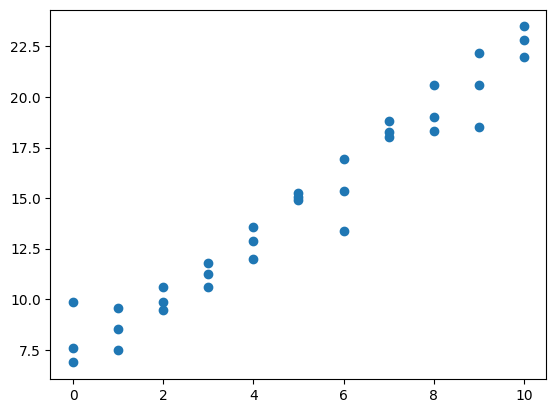

[1.50545379]


In [2]:
#import some modules needed
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
from sklearn import linear_model
rng = default_rng()
beta_0 = 7
beta_1 = 1.5
# get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
n = 33
#create the 'responses' modeled from the line plus a random deviation
y = beta_0 + beta_1*x + rng.standard_normal(n)
#visualize the data
plt.scatter(x = x, y = y)
plt.show()
reg = linear_model.LinearRegression()
reg.fit(x.reshape(-1,1),y)
print(reg.coef_)



Now I am going to create my For loop to generate my random data, use sklearn to generate a slope using the coef_ attribute and then save it in a List using append so I can get my list of slopes. I had to change the type of the returned value to a float which I did by generating the array first and then appending the first value of the array (since my arrays only returned one value).

In [3]:
slopelist=[]
samplesize=list(range(4999))
for i in samplesize:
  #this is what makes it fully random
  rng = default_rng()
  beta_0 = 7
  beta_1 = 1.5
  # get three 'values' of x at each integer from 0 to 10.
  x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
  n = 33
  #create the 'responses' modeled from the line plus a random deviation
  y = beta_0 + beta_1*x + rng.standard_normal(n)
  reg = linear_model.LinearRegression()
  #I need to reshape the x value so it works with the .fit()
  reg.fit(x.reshape(-1,1),y)
  #this appends my generated slope into the list
  slope=reg.coef_.round(3)
  slopelist.append(slope[0])


Just checking my list was created.

In [4]:
slopelist

[np.float64(1.52),
 np.float64(1.499),
 np.float64(1.517),
 np.float64(1.443),
 np.float64(1.484),
 np.float64(1.537),
 np.float64(1.482),
 np.float64(1.523),
 np.float64(1.557),
 np.float64(1.518),
 np.float64(1.465),
 np.float64(1.475),
 np.float64(1.513),
 np.float64(1.438),
 np.float64(1.516),
 np.float64(1.559),
 np.float64(1.459),
 np.float64(1.477),
 np.float64(1.436),
 np.float64(1.544),
 np.float64(1.53),
 np.float64(1.474),
 np.float64(1.511),
 np.float64(1.404),
 np.float64(1.453),
 np.float64(1.576),
 np.float64(1.516),
 np.float64(1.482),
 np.float64(1.527),
 np.float64(1.456),
 np.float64(1.433),
 np.float64(1.528),
 np.float64(1.468),
 np.float64(1.575),
 np.float64(1.493),
 np.float64(1.603),
 np.float64(1.528),
 np.float64(1.587),
 np.float64(1.4),
 np.float64(1.47),
 np.float64(1.649),
 np.float64(1.568),
 np.float64(1.573),
 np.float64(1.581),
 np.float64(1.466),
 np.float64(1.492),
 np.float64(1.555),
 np.float64(1.478),
 np.float64(1.481),
 np.float64(1.482),
 np.f

##**Histogram**

Now I need to build my histogram. In order to do this I first turned my list into a pandas series so that I could use my .hist() to create my histogram. I decided that I wanted my bins to be 20 so I could have a prettier graph.

<Axes: >

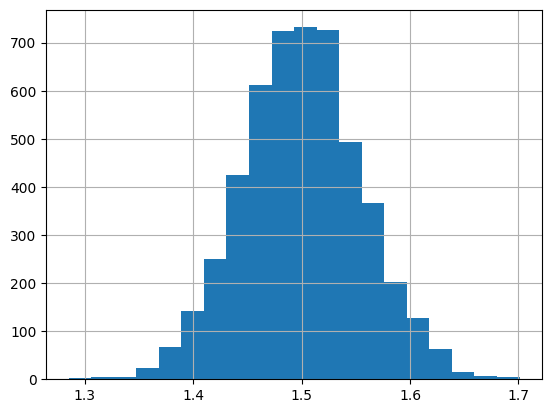

In [5]:
import pandas as pd
slopeseries= pd.Series(slopelist)
slopeseries.hist(bins=20)

##**Proportion**

Next we are going to do the proportion higher than 1.65. To do this I needed to basically do a count if. So, I created a conditional list that only contained the numbers from my original slope list that were larger than 1.65 and found the length of that list. I then did the proportion by doing (the number of items > 1.65)/5000.

In [6]:
sum1 = len([x for x in slopelist if x > 1.65])
prop = sum1/5000
print(prop)

0.0028


This number translates to there being a 0.48% chance to get a slope of this regression higher than 1.65. In the context of a hypothesis test, if we got a slope from our data that was >1.65 we would be 99.5% confident that the null hypothesis (the two data sets are the same) is false. Conversely if our slope was < 1.65 we would have confirmed the null hypothesis.

#**Part 3: Articles**

##**Question 5**

##**Question 6**

##**Question 7**

#**Part 4: SQL with Database**

Just making sure I have access to the file and database. I called my connection MLB to remind myself what the meaning of the database is. Things from MLB.

In [35]:
#bring in the module
import sqlite3
#make the connection to the file. My file is in the main folder on the left
MLB = sqlite3.connect("lahman_1871-2022.sqlite")

##**Question 8**

I need to look at all of the possible tables and columns in them before I can do the rest of the assignment. The `*` gives me all of the avalible information and the schema is a table alredy inherent that records type, name, and the sql codes needed to reference columns from a table.
I did this using `pd.read_sql()`.

In [51]:
#use the pd.read_sql() to return a dataframe
# SQL selects all columns from the schema where the type is a table
pd.read_sql('SELECT * FROM sqlite_schema \
            WHERE type = "table"',MLB)

,type,name,tbl_name,rootpage,sql
0,table,AllstarFull,AllstarFull,2,"CREATE TABLE AllstarFull (\nplayerID TEXT,\nye..."
1,table,Appearances,Appearances,3,"CREATE TABLE Appearances (\nyearID INTEGER,\nt..."
2,table,AwardsManagers,AwardsManagers,4,"CREATE TABLE AwardsManagers (\nplayerID TEXT,\..."
3,table,AwardsPlayers,AwardsPlayers,5,"CREATE TABLE AwardsPlayers (\nplayerID TEXT,\n..."
4,table,AwardsShareManagers,AwardsShareManagers,6,CREATE TABLE AwardsShareManagers (\nawardID TE...
5,table,AwardsSharePlayers,AwardsSharePlayers,7,CREATE TABLE AwardsSharePlayers (\nawardID TEX...
6,table,Batting,Batting,8,"CREATE TABLE Batting (\nplayerID TEXT,\nyearID..."
7,table,BattingPost,BattingPost,9,"CREATE TABLE BattingPost (\nyearID INTEGER,\nr..."
8,table,CollegePlaying,CollegePlaying,10,"CREATE TABLE CollegePlaying (\nplayerID TEXT,\..."
9,table,Fielding,Fielding,11,"CREATE TABLE Fielding (\nplayerID TEXT,\nyearI..."


##**Question 9**

I used the `WHERE` function to specify what conditions to sort my returned rows by. The `*` returns all of the columns from the specified teams table.

In [50]:
#use the pd.read_sql() to return a dataframe
# SQL selects all columns from teams where the year is 2015
pd.read_sql('SELECT * FROM teams \
              WHERE yearID =2015',MLB)


,yearID,lgID,teamID,franchID,divID,Rank,G,Ghome,W,L,...,DP,FP,name,park,attendance,BPF,PPF,teamIDBR,teamIDlahman45,teamIDretro
0,2015,AL,BAL,BAL,E,3,162,78,81,81,...,134,0.987,Baltimore Orioles,Oriole Park at Camden Yards,2281202,103,104,BAL,BAL,BAL
1,2015,AL,BOS,BOS,E,5,162,81,78,84,...,148,0.984,Boston Red Sox,Fenway Park II,2880694,104,107,BOS,BOS,BOS
2,2015,AL,CHA,CHW,C,4,162,81,76,86,...,159,0.983,Chicago White Sox,U.S. Cellular Field,1755810,92,93,CHW,CHA,CHA
3,2015,AL,CLE,CLE,C,3,161,80,81,80,...,136,0.987,Cleveland Indians,Progressive Field,1388905,106,106,CLE,CLE,CLE
4,2015,AL,DET,DET,C,5,161,81,74,87,...,165,0.986,Detroit Tigers,Comerica Park,2726048,97,98,DET,DET,DET
5,2015,AL,HOU,HOU,W,2,162,81,86,76,...,131,0.986,Houston Astros,Minute Maid Park,2153585,97,99,HOU,HOU,HOU
6,2015,AL,KCA,KCR,C,1,162,81,95,67,...,138,0.985,Kansas City Royals,Kauffman Stadium,2708549,104,103,KCR,KCA,KCA
7,2015,AL,LAA,ANA,W,3,162,81,85,77,...,108,0.984,Los Angeles Angels of Anaheim,Angel Stadium of Anaheim,3012765,94,95,LAA,ANA,ANA
8,2015,AL,MIN,MIN,C,2,162,81,83,79,...,150,0.986,Minnesota Twins,Target Field,2220054,103,104,MIN,MIN,MIN
9,2015,AL,NYA,NYY,E,2,162,81,87,75,...,135,0.985,New York Yankees,Yankee Stadium III,3193795,99,101,NYY,NYA,NYA


##**Question 10**

For this read call I needed to specify certain columns from the table HallOfFame to return. I checked the schema to get the correct column names for the information I wanted.

In [48]:
#I used pd.read_sql() to return a dataframe
#Select was used to specify which columns I wanted to see
#from the table HallOfFame
pd.read_sql('SELECT playerID, yearID, category \
            FROM HallOfFame', MLB)

,playerID,yearid,category
0,aaronha01,1982,Player
1,abbotji01,2005,Player
2,abreubo01,2020,Player
3,abreubo01,2021,Player
4,abreubo01,2022,Player
...,...,...,...
4318,zambrca01,2018,Player
4319,zeileto01,2010,Player
4320,zimmech01,1938,Player
4321,ziskri01,1989,Player


##**Question 11**

For this query we had to only choose distinct managers (aka get rid of duplicates) from the managers table. We also sorted for spesifically managers from the Pittsburgh Pirates. I used `SELECT DISTINCT` to avoid repeats and then `WHERE` to sort for the teamID Pit. I used "" around PIT to show it was text.

In [96]:
#I used pd.read_sql to get the data from my database
#I wanted SELECT DISTINCT to avoid repetition
#I also used WHERE to get a spesific team (Pittsburgh Pirates)
pd.read_sql('SELECT DISTINCT playerID \
              FROM Managers \
              WHERE teamID = "PIT" ', MLB)

,playerID
0,bezdehu99
1,bragabo01
2,buckeal99
3,burnsto01
4,burwebi01
5,bushdo01
6,callani01
7,clarkfr01
8,davissp01
9,donovpa01


##**Question 12**

I knew that I wanted to count the total number of people who have both managed teams and gotten into the Hall of Fame. Thus, I used the `SELECT DISTINCT` to avoid repetition. I needed to use `INNER JOIN` to get data from both the Managers table and the Hall of Fame table. Controlled the results by using the `ON` to specify that I wanted their names to be the same. I then used the `len()` method on the dataframe to count how many managers there have been.

In [58]:
#I needed to save this one as a variable so I could use len() on it later.
#I used select distinct to avoid repetition
#I then used inner join to get common data from Managers and HallofFame
#I specified that I wanted their names to be the same using ON
Famemanage = pd.read_sql('SELECT DISTINCT h.playerID\
                          FROM HallOfFame as h \
                          INNER JOIN Managers as m\
                          ON h.playerID = m.playerID', MLB)
Famemanage

,playerID
0,allisdo01
1,alomasa02
2,aloufe01
3,alstowa01
4,andersp01
...,...
245,wrighge01
246,wrighha01
247,yorkru01
248,youngcy01


In [59]:
#I then found the length of the dataframe
#This was done to count the number of people who were
#in the hall of fame and managers of their team
len(Famemanage)

250

##**Question 13**

The first part of this question was basically like question 12 except I asked for more columns as a response. I also had to make it no longer distinct so I could get all of the seasons. I also decided to use a GROUP BY to sort the season by name to make the chart easier to read.

For the second part, I decided to do the math for this using SQL because I wanted to practice it. I generated the sum versions of wins and losses using `SUM()` the `GROUP BY` was used to make sure the `SUM()` acted based on the name of the manager.

I did the percentage by creating a column named Win_Loss_Percentage. I created a numerical operation (`(SUM(m.W)*1.0)/SUM(m.G)`) this was still sorted using `GROUP BY` and named using `AS`. I then ordered it by the new column using `ORDER BY __ DESC`.

In [101]:
#pd.read_sql of MLB to get dataframe response
#I used SELECT for name, G, W, and L.
#They have a little letter and . to make it shorter.
#This was done during the INNER JOIN using AS
#I then used GROUP BY for readability
pd.read_sql('SELECT h.playerID, m.G, m.W, m.L \
                      FROM HallOfFame AS h \
                      INNER JOIN Managers AS m \
                      ON h.playerID = m.playerID\
                      GROUP BY h.playerID', MLB)


,playerID,G,W,L
0,allisdo01,23,2,21
1,alomasa02,6,3,3
2,aloufe01,125,70,55
3,alstowa01,154,92,62
4,andersp01,162,102,60
...,...,...,...,...
245,wrighge01,85,59,25
246,wrighha01,31,20,10
247,yorkru01,1,0,1
248,youngcy01,6,3,3


In [102]:
#I used pd.read_sql of MLB to get dataframe response
#The basics of this copied the code above
#I did add a column named win_loss_percentage
#This column was defined as (SUM(m.W)*1.0)/SUM(m.G)
#The 1.0 makes it a float so there is decimals in the answer
#I also did the ORDER BY __ DESC to get it in the correct order.
pd.read_sql('SELECT h.playerID,SUM(m.W),SUM(m.L),\
                       (SUM(m.W)*1.0)/SUM(m.G) AS Win_Loss_Percentage\
                        FROM HallOfFame as h INNER JOIN Managers as m \
                        ON h.playerID = m.playerID \
                        GROUP BY h.playerID \
                        ORDER BY Win_Loss_Percentage DESC', MLB)


,playerID,SUM(m.W),SUM(m.L),Win_Loss_Percentage
0,hardeme01,39,0,1.000000
1,simmote01,2,0,1.000000
2,steinte01,2,0,1.000000
3,sukefcl01,2,0,1.000000
4,speiech01,14,4,0.777778
...,...,...,...,...
245,paborch01,13,64,0.168831
246,vanhage01,1,10,0.090909
247,allisdo01,2,21,0.086957
248,lathaar01,0,9,0.000000
